# Cybersecurity Incident Triage AI

## Domain : Cybersecurity

### About the Domain

Cybersecurity focuses on protecting computer systems, networks, applications, and data from unauthorized access, attacks, and other security threats.

Security Operations Centers (SOCs) receive a large number of security alerts from different security systems. Analyzing these alerts manually can be time-consuming and can lead to alert fatigue.

Artificial Intelligence can help security analysts analyze alerts, identify suspicious network behavior, enrich alerts with threat intelligence, retrieve relevant cybersecurity knowledge, and provide explanations and recommended actions.

## Business Problem Statement

Security Operations Centers receive a large volume of security alerts from network monitoring systems, endpoint security systems, authentication systems, firewalls, and SIEM platforms.

Manually investigating every alert is time-consuming and may result in alert fatigue, delayed investigation, and difficulty identifying genuine security incidents among large numbers of alerts.

A system is therefore needed to intelligently analyze security alerts, identify suspicious network behavior, prioritize important alerts, enrich them with threat intelligence, retrieve relevant cybersecurity knowledge, and provide contextual explanations and recommended actions to help SOC analysts make faster and better decisions.

## Objective

Develop an AI-powered Cybersecurity Incident Triage Assistant that helps SOC analysts analyze and prioritize security alerts.

The system aims to:

- Analyze network security alerts and identify suspicious behavior.
- Classify network activity based on known attack patterns.
- Enrich alerts using threat intelligence sources.
- Retrieve relevant cybersecurity knowledge using RAG.
- Generate explanations for why an alert may be suspicious.
- Recommend appropriate investigation or response actions.
- Keep the final decision under the control of the human security analyst.

## Dataset Source

- **Dataset:** Network Behavior Dataset (CIC-IDS2017)
- **Source:** Canadian Institute for Cybersecurity (CIC)
- **Dataset Type:** Network traffic / intrusion detection dataset
- **Purpose:** Analyze normal and malicious network behavior
- **Target Column (Y):** `Label`
- **Final Dataset:** `cic_ids2017_final.csv`

## Dataset Description

The Network Behavior Dataset (CIC-IDS2017) contains network traffic records representing both benign and malicious network behavior.

Each record contains numerical network-flow features describing characteristics of network communication, along with a `Label` column that identifies the type of network activity.

The dataset contains multiple attack categories such as:

- BENIGN
- DoS
- DDoS
- PortScan
- Brute Force
- Bot
- Web Attacks
- Infiltration
- Heartbleed

This dataset is mainly used in this project to understand network behavior and support security alert triage.


# 0.Data: Collection & Loading 
#### Modules
All libraries used in this notebook.


In [22]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [21]:

# Load Network Behavior Dataset

from pathlib import Path

DATA_PATH = Path("../data/processed/Network Behavior Dataset.csv")

df_raw = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Dataset Shape:", df_raw.shape)

Dataset loaded successfully
Dataset Shape: (2522009, 25)


#### Dataset Overview

The Network Behavior Dataset (CIC-IDS2017) contains network traffic records representing normal and malicious network behavior. It provides numerical network-flow features that can be used to analyze and identify different types of cybersecurity attacks.

The dataset is used in this project to support security alert analysis and incident triage.

#### Basic Raw Data Checks
Load the table directly from the database and take a first look at it before doing anything else.


In [34]:
# Dataset Overview

print("Dataset Shape:")
print(df_raw.shape)

print("\nColumn Names:")
print(df_raw.columns.tolist())

print("\nData Types:")
print(df_raw.dtypes)

Dataset Shape:
(2522009, 25)

Column Names:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Fwd IAT Mean', 'Bwd IAT Mean', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'Label']

Data Types:
Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
Total Length of Bwd Packets      int64
Fwd Packet Length Max            int64
Fwd Packet Length Mean         float64
Bwd Packet Length Max            int64
Bwd Packet Length Mean         float64
Flow Bytes/s                  

In [26]:
# First 5 Records

df_raw.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Mean,Bwd Packet Length Max,Bwd Packet Length Mean,...,Bwd IAT Mean,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,Average Packet Size,Init_Win_bytes_forward,Init_Win_bytes_backward,Label
0,54865,3,2,0,12,0,6,6.0,0,0.0,...,0.0,0,0,0,0,1,9.0,33,-1,BENIGN
1,55054,109,1,1,6,6,6,6.0,6,6.0,...,0.0,0,0,0,0,1,9.0,29,256,BENIGN
2,55055,52,1,1,6,6,6,6.0,6,6.0,...,0.0,0,0,0,0,1,9.0,29,256,BENIGN
3,46236,34,1,1,6,6,6,6.0,6,6.0,...,0.0,0,0,0,0,1,9.0,31,329,BENIGN
4,54863,3,2,0,12,0,6,6.0,0,0.0,...,0.0,0,0,0,0,1,9.0,32,-1,BENIGN


In [27]:
# Last 5 Records

df_raw.tail()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Mean,Bwd Packet Length Max,Bwd Packet Length Mean,...,Bwd IAT Mean,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,Average Packet Size,Init_Win_bytes_forward,Init_Win_bytes_backward,Label
2522004,53,32215,4,2,112,152,28,28.0,76,76.0,...,3.0,0,0,0,0,0,48.666667,-1,-1,BENIGN
2522005,53,324,2,2,84,362,42,42.0,181,181.0,...,2.0,0,0,0,0,0,122.000000,-1,-1,BENIGN
2522006,58030,82,2,1,31,6,31,15.5,6,6.0,...,0.0,0,1,0,0,1,22.666667,1006,0,BENIGN
2522007,53,1048635,6,2,192,256,32,32.0,128,128.0,...,3.0,0,0,0,0,0,60.000000,-1,-1,BENIGN
2522008,53,94939,4,2,188,226,47,47.0,113,113.0,...,48.0,0,0,0,0,0,76.833333,-1,-1,BENIGN


**Column data types and non-null counts**

In [29]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2522009 entries, 0 to 2522008
Data columns (total 25 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Mean       float64
 8   Bwd Packet Length Max        int64  
 9   Bwd Packet Length Mean       float64
 10  Flow Bytes/s                 float64
 11  Flow Packets/s               float64
 12  Flow IAT Mean                float64
 13  Flow IAT Std                 float64
 14  Fwd IAT Mean                 float64
 15  Bwd IAT Mean                 float64
 16  FIN Flag Count               int64  
 17  SYN Flag Count               int64  
 18  RST Flag Count               int64  
 19  

**Numeric summary**

In [31]:
df_raw.describe()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Mean,Bwd Packet Length Max,Bwd Packet Length Mean,...,Fwd IAT Mean,Bwd IAT Mean,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,Average Packet Size,Init_Win_bytes_forward,Init_Win_bytes_backward
count,2.522009e+06,2.522009e+06,2.522009e+06,2.522009e+06,2.522009e+06,2.522009e+06,2.522009e+06,2.522009e+06,2.522009e+06,2.522009e+06,...,2.522009e+06,2.522009e+06,2.522009e+06,2.522009e+06,2.522009e+06,2.522009e+06,2.522009e+06,2.522009e+06,2.522009e+06,2.522009e+06
mean,8.701432e+03,1.658364e+07,1.027750e+01,1.156751e+01,6.116607e+02,1.813569e+04,2.311241e+02,6.347899e+01,9.745064e+02,3.404609e+02,...,2.917855e+06,2.026761e+06,3.214540e-02,4.874487e-02,2.720054e-04,2.975608e-01,3.120964e-01,2.123412e+02,7.265225e+03,2.230333e+03
std,1.902225e+04,3.522618e+07,7.942294e+02,1.056668e+03,1.058573e+04,2.397602e+06,7.562104e+02,1.955137e+02,2.037969e+03,6.324553e+02,...,1.001419e+07,9.391236e+06,1.763862e-01,2.153342e-01,1.649035e-02,4.571854e-01,4.633490e-01,3.454504e+02,1.459783e+04,8.926886e+03
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,-1.000000e+00
25%,5.300000e+01,2.080000e+02,2.000000e+00,1.000000e+00,1.200000e+01,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,...,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+00,-1.000000e+00,-1.000000e+00
50%,8.000000e+01,5.058700e+04,2.000000e+00,2.000000e+00,6.600000e+01,1.560000e+02,4.000000e+01,3.613084e+01,9.700000e+01,8.800000e+01,...,4.900000e+01,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.075000e+01,2.510000e+02,0.000000e+00
75%,4.430000e+02,5.330376e+06,6.000000e+00,5.000000e+00,3.320000e+02,9.910000e+02,2.020000e+02,5.200000e+01,7.460000e+02,2.180000e+02,...,7.372906e+05,2.969120e+04,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.796923e+02,8.192000e+03,2.350000e+02
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,5.940857e+03,1.953000e+04,5.800500e+03,...,1.200000e+08,1.200000e+08,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.893333e+03,6.553500e+04,6.553500e+04


# 1. Data Validation & Feature Preparation 

Before proceeding with further analysis, the dataset is validated to ensure that the numerical network-flow features are in a usable format.

The validation checks for missing values, infinite values, incorrect data types, and duplicate records.

Normalization is also considered because the network-flow features have very different numerical scales. Scaling the features will be performed later during model preprocessing so that the original dataset remains unchanged.

In [32]:
# Data Validation

print("Missing Values:")
print(df_raw.isnull().sum().sum())

print("\nInfinite Values:")
print(np.isinf(df_raw.select_dtypes(include=np.number)).sum().sum())

print("\nDuplicate Rows:")
print(df_raw.duplicated().sum())

print("\nNon-Numeric Feature Columns:")
print(df_raw.drop(columns=["Label"]).select_dtypes(exclude=np.number).columns.tolist())

Missing Values:
0

Infinite Values:
0

Duplicate Rows:
42187

Non-Numeric Feature Columns:
[]


In [33]:
# Validation Summary

validation_summary = {
    "Total Rows": len(df_raw),
    "Total Columns": len(df_raw.columns),
    "Missing Values": df_raw.isnull().sum().sum(),
    "Infinite Values": np.isinf(
        df_raw.select_dtypes(include=np.number)
    ).sum().sum(),
    "Duplicate Rows": df_raw.duplicated().sum()
}

pd.Series(validation_summary)

Total Rows         2522009
Total Columns           25
Missing Values           0
Infinite Values          0
Duplicate Rows       42187
dtype: int64

## 1.2. Target / Label Analysis

The `Label` column represents the type of network activity observed in each record.

It contains both normal network traffic (`BENIGN`) and different types of malicious activities.

Analyzing the label distribution helps us understand the different security events present in the dataset and identify whether the dataset is balanced or imbalanced.

In [35]:
# Target / Label Analysis

label_counts = df_raw["Label"].value_counts()

print("Number of Unique Labels:", df_raw["Label"].nunique())

print("\nLabel Counts:")
print(label_counts)

Number of Unique Labels: 15

Label Counts:
Label
BENIGN                        2096134
DoS Hulk                       172846
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack - Brute Force         1470
Web Attack - XSS                  652
Infiltration                       36
Web Attack - SQL Injection         21
Heartbleed                         11
Name: count, dtype: int64


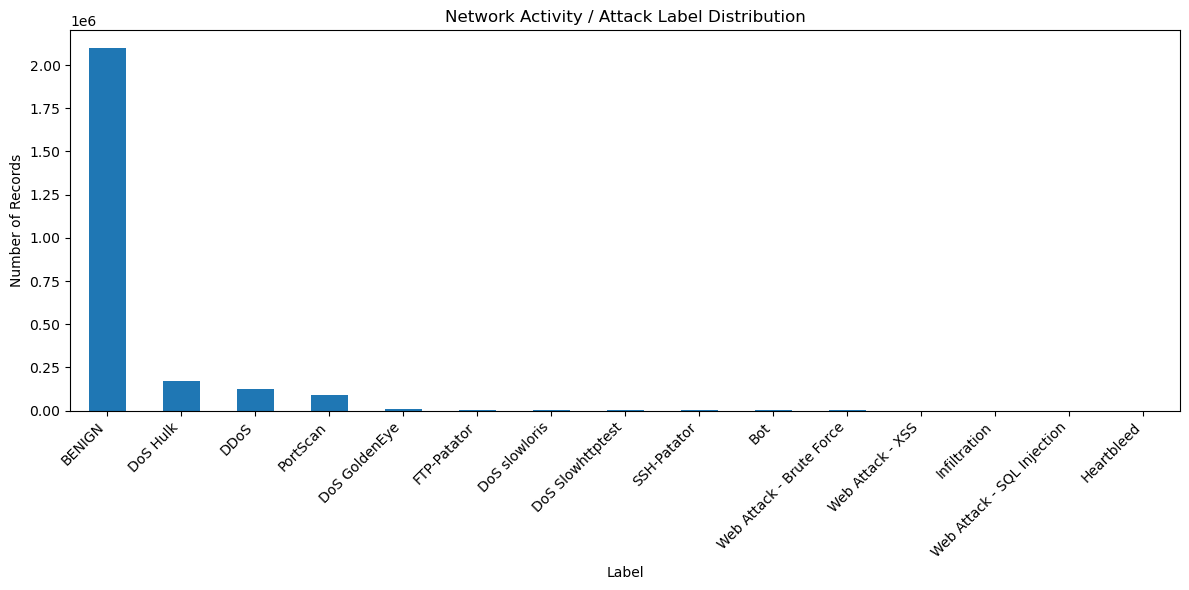

In [39]:
#Plot
plt.figure(figsize=(12, 6))

label_counts.plot(kind="bar")

plt.title("Network Activity / Attack Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

##  1.3. Benign vs Attack Analysis

The dataset contains both normal (`BENIGN`) and malicious network traffic.

For cybersecurity incident triage, it is important to understand how much of the traffic is normal compared with potentially malicious activity.

This analysis provides a high-level view of the proportion of benign and attack traffic.

In [40]:
# Create high-level traffic category

df_raw["Traffic_Type"] = np.where(
    df_raw["Label"].str.upper() == "BENIGN",
    "Benign",
    "Attack"
)

traffic_counts = df_raw["Traffic_Type"].value_counts()

print("Benign vs Attack:")
print(traffic_counts)

Benign vs Attack:
Traffic_Type
Benign    2096134
Attack     425875
Name: count, dtype: int64


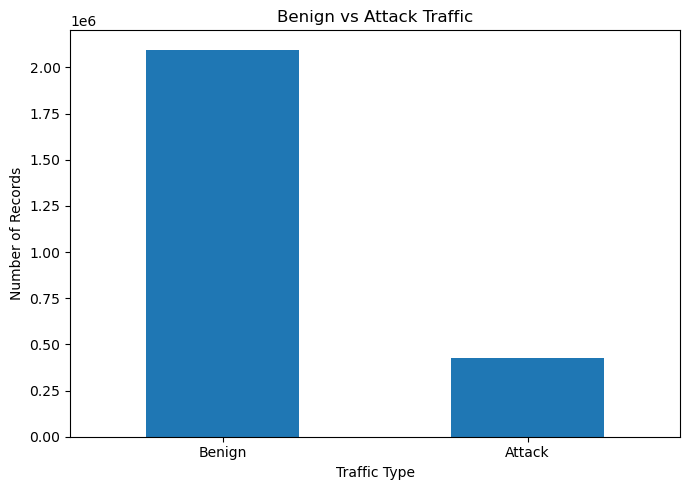

In [41]:
#Plot
plt.figure(figsize=(7, 5))

traffic_counts.plot(kind="bar")

plt.title("Benign vs Attack Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [43]:
#Percentage
traffic_percentage = (
    df_raw["Traffic_Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Traffic Percentage:")
print(traffic_percentage)

Traffic Percentage:
Traffic_Type
Benign    83.11
Attack    16.89
Name: proportion, dtype: float64


### 1.4. Attack Family Analysis

The original `Label` column contains detailed attack names.

For cybersecurity incident triage, these detailed labels can also be grouped into broader attack families. This makes the results easier to interpret and helps summarize related security events.

The original `Label` values are retained and are not replaced.

In [44]:
# Map detailed labels into broader attack families

def get_attack_family(label):
    label_lower = str(label).lower()

    if label_lower == "benign":
        return "Benign"
    elif "ddos" in label_lower:
        return "DDoS"
    elif "dos" in label_lower:
        return "DoS"
    elif "portscan" in label_lower:
        return "Reconnaissance"
    elif "patator" in label_lower or "brute force" in label_lower:
        return "Brute Force"
    elif "sql injection" in label_lower:
        return "SQL Injection"
    elif "xss" in label_lower:
        return "XSS"
    elif "bot" in label_lower:
        return "Bot/Botnet"
    elif "infiltration" in label_lower:
        return "Infiltration"
    elif "heartbleed" in label_lower:
        return "Vulnerability Exploitation"
    else:
        return "Other"


df_raw["Attack_Family"] = df_raw["Label"].apply(get_attack_family)

family_counts = df_raw["Attack_Family"].value_counts()

print("Attack Family Counts:")
print(family_counts)

Attack Family Counts:
Attack_Family
Benign                        2096134
DoS                            193745
DDoS                           128016
Reconnaissance                  90819
Brute Force                     10622
Bot/Botnet                       1953
XSS                               652
Infiltration                       36
SQL Injection                      21
Vulnerability Exploitation         11
Name: count, dtype: int64


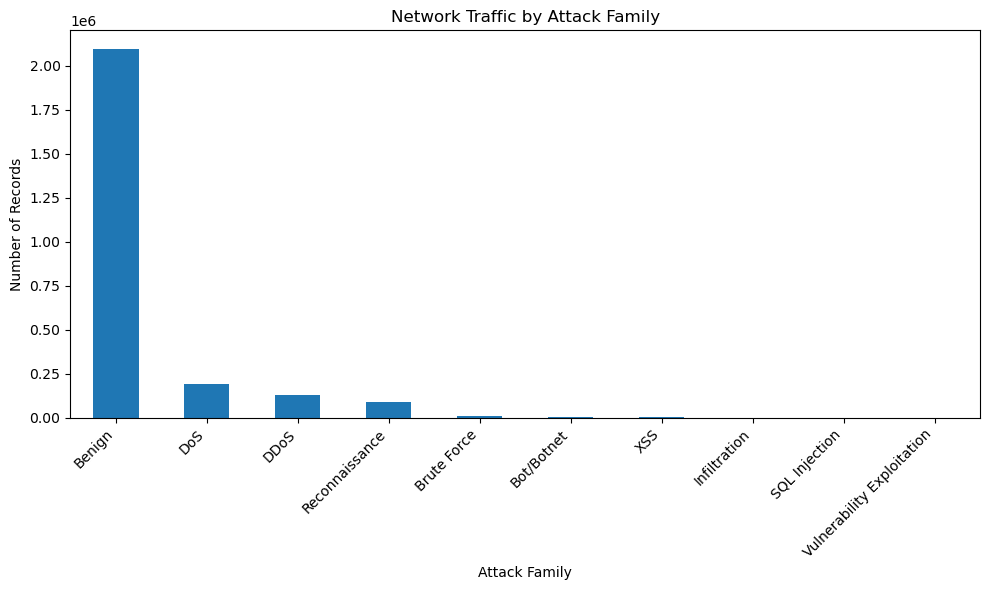

In [45]:
#plot
plt.figure(figsize=(10, 6))

family_counts.plot(kind="bar")

plt.title("Network Traffic by Attack Family")
plt.xlabel("Attack Family")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# 2.EDA Analysis (Uni, Bi, Corre ) 

The Network Behavior Dataset contains numerical features describing network-flow characteristics such as packet counts, packet lengths, flow rates, TCP flags, and window sizes.

Because the dataset contains more than 2.5 million records, a representative sample is used for visualization to make the plots efficient while preserving the overall distribution patterns.

In [46]:
# Create a sample for visualization

eda_sample = df_raw.sample(
    n=min(100000, len(df_raw)),
    random_state=42
)

print("EDA Sample Shape:", eda_sample.shape)

EDA Sample Shape: (100000, 27)


### 2.1 Univariate Analysis
Univariate analysis examines one variable at a time.

For this project, important network-flow features such as Flow Duration, Flow Packets/s, and Flow Bytes/s are analyzed individually to understand their distributions and network behavior.

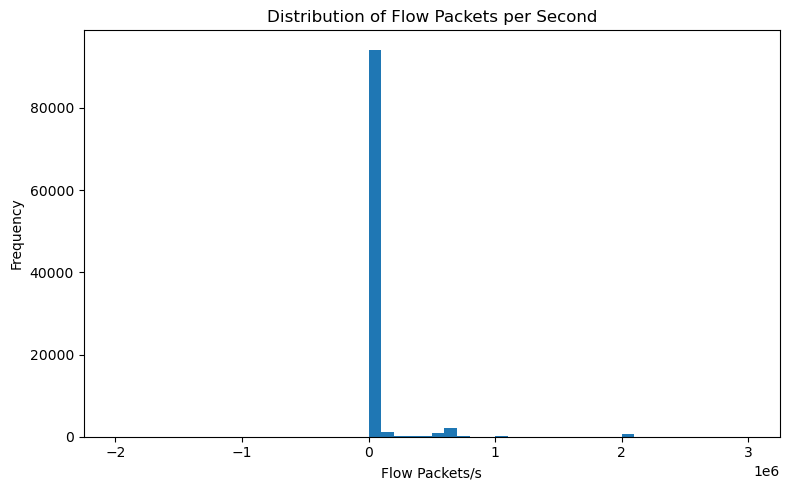

In [49]:
#Flow Packets/s
plt.figure(figsize=(8, 5))

values = (
    eda_sample["Flow Packets/s"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

plt.hist(values, bins=50)

plt.title("Distribution of Flow Packets per Second")
plt.xlabel("Flow Packets/s")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

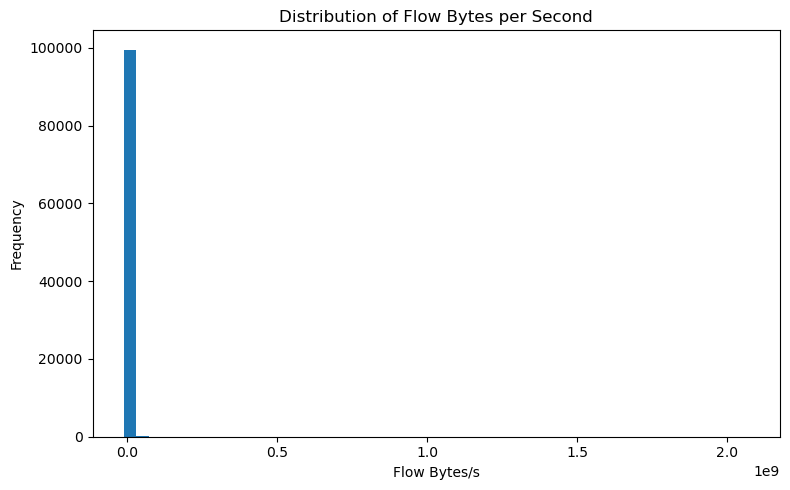

In [50]:
# 2. Flow Bytes/s
plt.figure(figsize=(8, 5))

values = (
    eda_sample["Flow Bytes/s"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

plt.hist(values, bins=50)

plt.title("Distribution of Flow Bytes per Second")
plt.xlabel("Flow Bytes/s")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

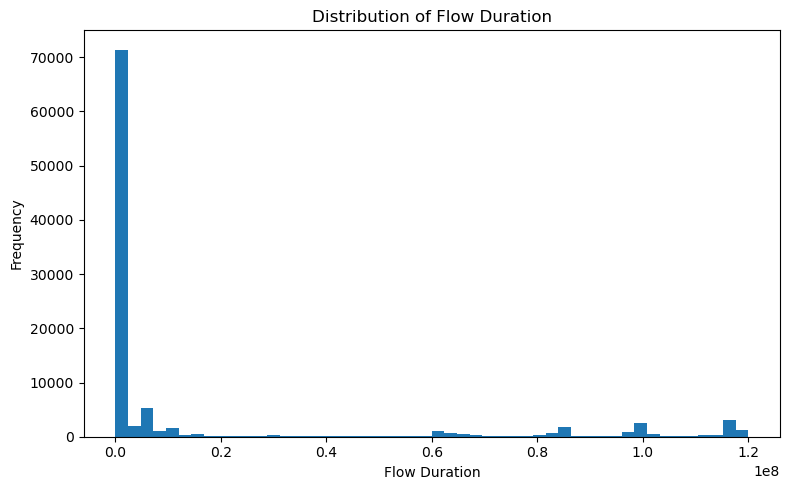

In [51]:
# Univariate Analysis - Flow Duration

plt.figure(figsize=(8, 5))

plt.hist(
    eda_sample["Flow Duration"],
    bins=50
)

plt.title("Distribution of Flow Duration")
plt.xlabel("Flow Duration")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 2.2 Bivariate Analysis

C:\Users\DEKSHITH\AppData\Local\Temp\ipykernel_5868\3247369311.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


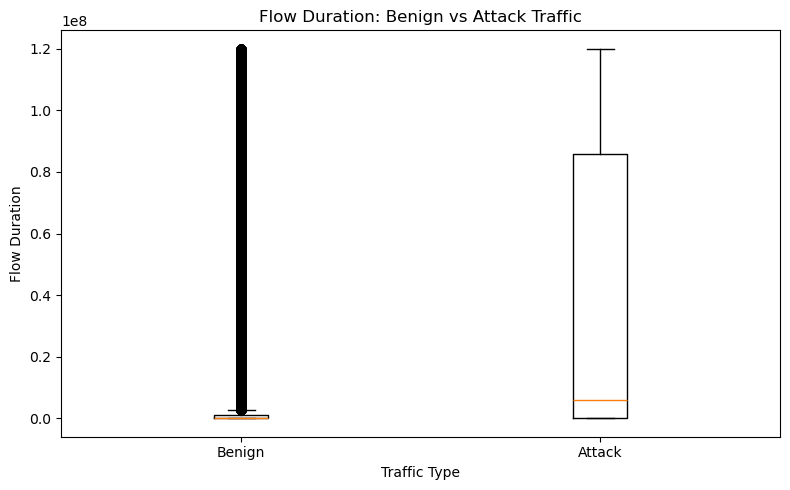

In [53]:
# Bivariate Analysis - Flow Duration vs Traffic Type

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        eda_sample.loc[eda_sample["Traffic_Type"] == "Benign", "Flow Duration"],
        eda_sample.loc[eda_sample["Traffic_Type"] == "Attack", "Flow Duration"]
    ],
    labels=["Benign", "Attack"]
)

plt.title("Flow Duration: Benign vs Attack Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Flow Duration")

plt.tight_layout()
plt.show()

C:\Users\DEKSHITH\AppData\Local\Temp\ipykernel_5868\1991449636.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


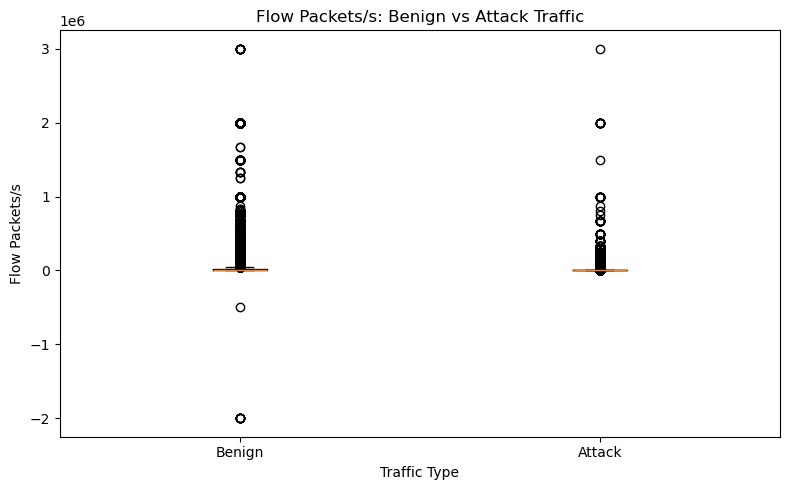

In [54]:
# Bivariate Analysis - Flow Packets/s vs Traffic Type

plt.figure(figsize=(8, 5))

benign_packets = (
    eda_sample.loc[
        eda_sample["Traffic_Type"] == "Benign",
        "Flow Packets/s"
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

attack_packets = (
    eda_sample.loc[
        eda_sample["Traffic_Type"] == "Attack",
        "Flow Packets/s"
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

plt.boxplot(
    [benign_packets, attack_packets],
    labels=["Benign", "Attack"]
)

plt.title("Flow Packets/s: Benign vs Attack Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Flow Packets/s")

plt.tight_layout()
plt.show()

C:\Users\DEKSHITH\AppData\Local\Temp\ipykernel_5868\3619414895.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


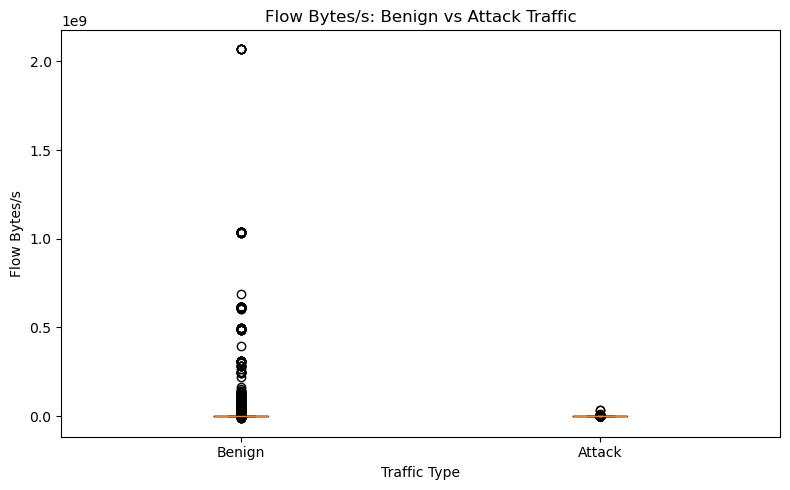

In [55]:
# Bivariate Analysis - Flow Bytes/s vs Traffic Type

plt.figure(figsize=(8, 5))

benign_bytes = (
    eda_sample.loc[
        eda_sample["Traffic_Type"] == "Benign",
        "Flow Bytes/s"
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

attack_bytes = (
    eda_sample.loc[
        eda_sample["Traffic_Type"] == "Attack",
        "Flow Bytes/s"
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

plt.boxplot(
    [benign_bytes, attack_bytes],
    labels=["Benign", "Attack"]
)

plt.title("Flow Bytes/s: Benign vs Attack Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Flow Bytes/s")

plt.tight_layout()
plt.show()

## 2.3 Multivariate Analysis - Correlation Matrix

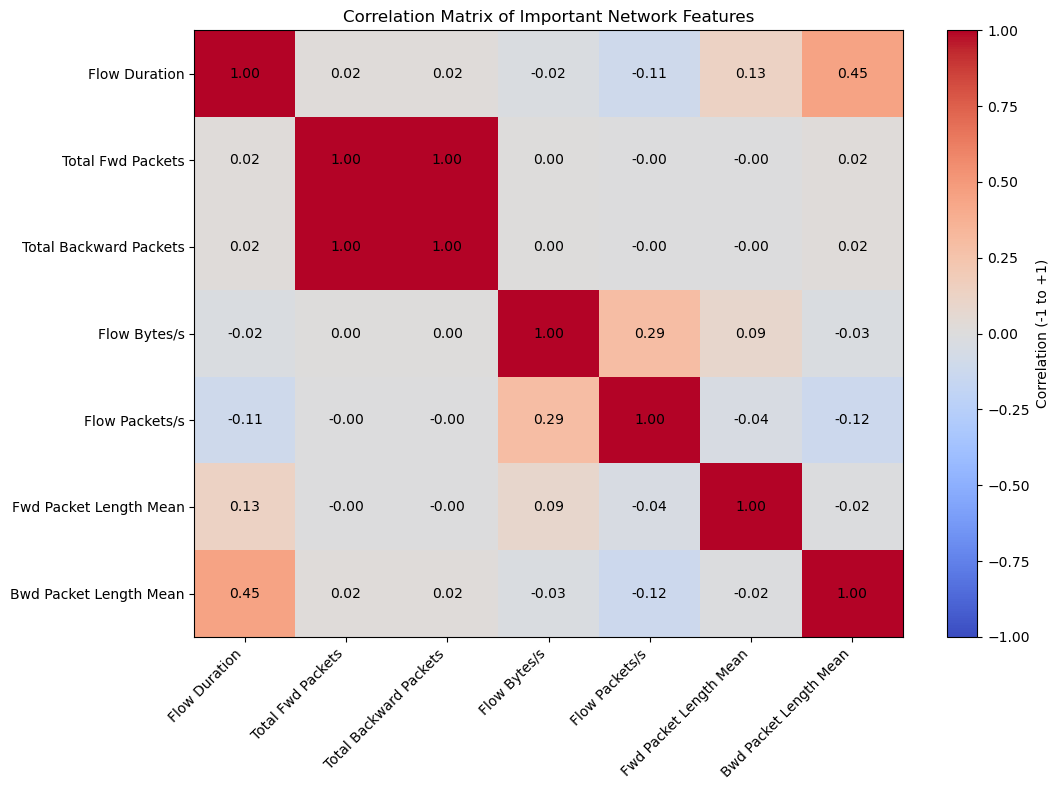

In [65]:
# 8.1 Multivariate Analysis - Correlation Matrix

important_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean"
]

correlation_matrix = eda_sample[important_features].corr()

plt.figure(figsize=(11, 8))

plt.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlation (-1 to +1)")

plt.xticks(
    range(len(important_features)),
    important_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(important_features)),
    important_features
)

# Display correlation values
for i in range(len(important_features)):
    for j in range(len(important_features)):
        value = correlation_matrix.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=10
        )

plt.title("Correlation Matrix of Important Network Features")

plt.tight_layout()
plt.show()

# 9. Outlier Analysis

Outlier analysis identifies unusually high or low values in network-flow features.

In cybersecurity data, extreme values can represent unusual network behavior or attack-related traffic. Therefore, outliers should be analyzed carefully rather than automatically removed.

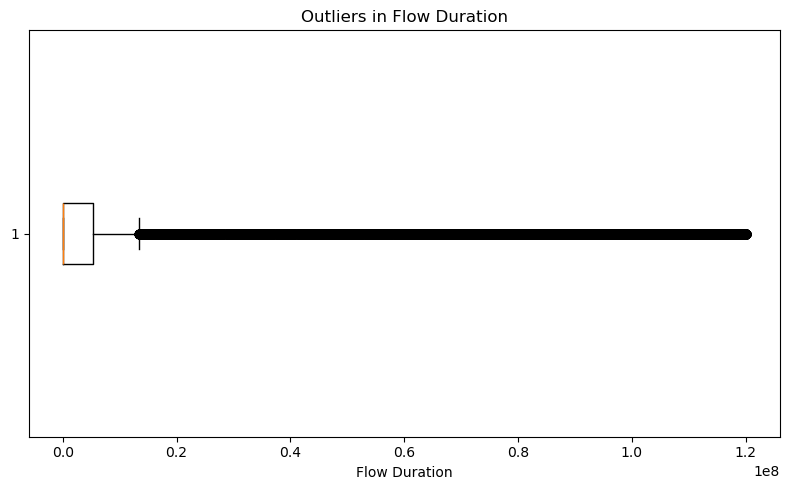

In [59]:
# Outlier Analysis - Flow Duration

plt.figure(figsize=(8, 5))

values = eda_sample["Flow Duration"].dropna()

plt.boxplot(values, vert=False)

plt.title("Outliers in Flow Duration")
plt.xlabel("Flow Duration")

plt.tight_layout()
plt.show()

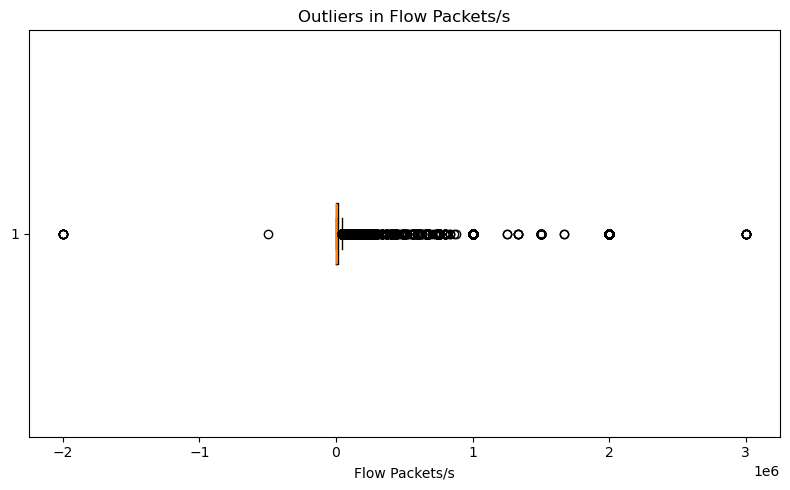

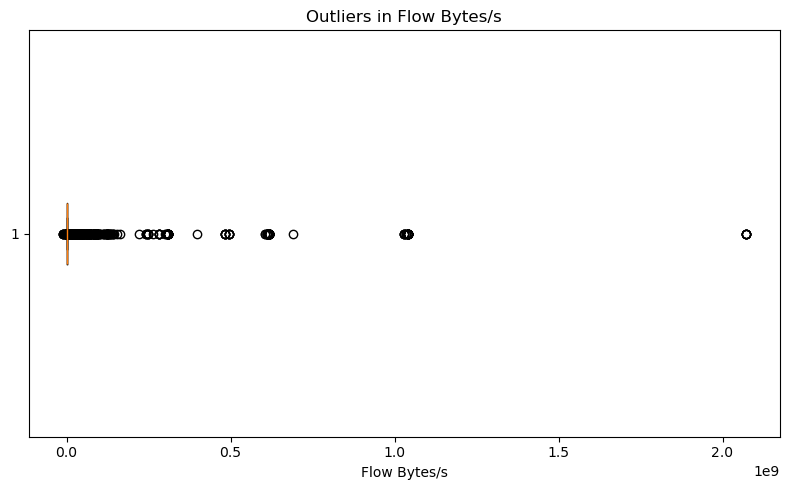

In [64]:
# Outlier Analysis - Flow Packets/s

plt.figure(figsize=(8, 5))

values = (
    eda_sample["Flow Packets/s"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

plt.boxplot(values, vert=False)

plt.title("Outliers in Flow Packets/s")
plt.xlabel("Flow Packets/s")

plt.tight_layout()
plt.show()

# Outlier Analysis - Flow Bytes/s

plt.figure(figsize=(8, 5))

values = (
    eda_sample["Flow Bytes/s"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

plt.boxplot(values, vert=False)

plt.title("Outliers in Flow Bytes/s")
plt.xlabel("Flow Bytes/s")

plt.tight_layout()
plt.show()

# 10. Rare Attack Analysis

Rare attack classes contain very few records compared with common attack classes.

Analyzing these classes is important because rare attacks may be difficult to detect and learn from during model development.

In [62]:
# 10.1 Rare Attack Classes

label_counts = eda_sample["Label"].value_counts()

rare_attacks = label_counts[
    (label_counts < 1000) &
    (label_counts.index != "BENIGN")
]

print("Rare Attack Classes:")
print(rare_attacks)

Rare Attack Classes:
Label
DoS GoldenEye               439
FTP-Patator                 251
DoS Slowhttptest            221
DoS slowloris               220
SSH-Patator                 140
Bot                          72
Web Attack - Brute Force     47
Web Attack - XSS             32
Name: count, dtype: int64


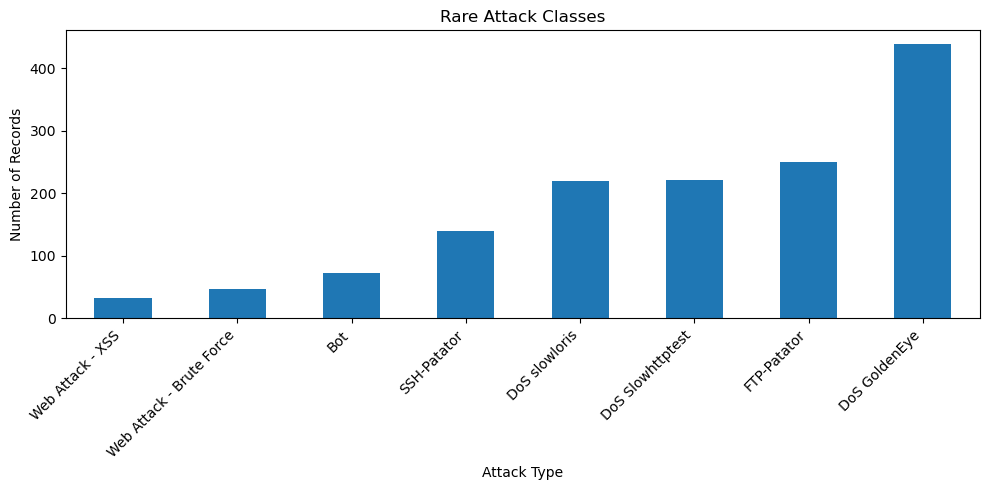

In [63]:
# 10.2 Rare Attack Distribution

plt.figure(figsize=(10, 5))

rare_attacks.sort_values().plot(kind="bar")

plt.title("Rare Attack Classes")
plt.xlabel("Attack Type")
plt.ylabel("Number of Records")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [66]:
# Check duplicates in the final dataset

duplicate_count = df_raw.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 42187


In [68]:
# Check exact duplicates after original data cleaning

clean_file = r"..\data\processed\cic_ids2017_clean.csv"

df_clean = pd.read_csv(clean_file)

print("Dataset shape:", df_clean.shape)
print("Exact duplicate rows:", df_clean.duplicated().sum())

Dataset shape: (2522009, 79)
Exact duplicate rows: 0
